In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import moviepy as mpy
from omegaconf import OmegaConf

os.environ["MUJOCO_GL"] = "egl"

repo_root = Path("/home/helix/projects/METRA-Projects/FlashSAC")
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from flash_rl.agents.metra.agent import METRAAgent
from flash_rl.agents.metra.sampler import Sampler
from flash_rl.envs.envs.mujoco.ant_env import AntEnv

def _latest_checkpoint_path(root: Path) -> Path:
    run_dirs = sorted([path for path in root.glob("seed*") if path.is_dir()])
    if not run_dirs:
        raise FileNotFoundError(f"No run directories found under {root}")

    latest_run = run_dirs[-1]
    checkpoint_paths = sorted(
        latest_run.glob("epoch*/agent_state.pt"),
        key=lambda path: int(path.parent.name.replace("epoch", "")),
    )
    if not checkpoint_paths:
        raise FileNotFoundError(f"No checkpoints found under {latest_run}")
    return checkpoint_paths[-1]

checkpoint_root = repo_root / "models" / "general" / "general_train"
checkpoint_override = checkpoint_root / "seed511527-0529-145128" / "epoch5000" / "agent_state.pt"
checkpoint_path = checkpoint_override if checkpoint_override.exists() else _latest_checkpoint_path(checkpoint_root)
resolved_cfg_path = checkpoint_path.parent.parent / "resolved_config.yaml"
cfg = OmegaConf.load(resolved_cfg_path)
agent_cfg = cfg.agent
video_dir = checkpoint_path.parent.parent / "eval_videos"
print(f"Using checkpoint: {checkpoint_path}")
print(f"Using resolved config: {resolved_cfg_path}")
print(f"Video output dir: {video_dir}")
print(OmegaConf.to_yaml(cfg))

Using checkpoint: /home/helix/projects/METRA-Projects/FlashSAC/models/general/general_train/seed511527-0529-145128/epoch5000/agent_state.pt
Using resolved config: /home/helix/projects/METRA-Projects/FlashSAC/models/general/general_train/seed511527-0529-145128/resolved_config.yaml
Video output dir: /home/helix/projects/METRA-Projects/FlashSAC/models/general/general_train/seed511527-0529-145128/eval_videos
agent:
  skill_dim: 2
  model_master_dim: 1024
  model_master_num_layers: 2
  spectral_normalization: false
  dual_lam: 30
  alpha: 0.01
  common_lr: 0.0001
  gamma: 0.99
  buffer_max_length: 300000
  buffer_min_length: 10000
  sample_batch_size: 256
  target_coef: 1.0
  dual_slack: 0.001
  discount: 0.99
  tau: 0.005
project_name: Metra
group_name: general
exp_name: general_train
seed: 511527
logger_type: tensorboard
save_path: models/general/general_train/seed511527-TIMESTAMP
logging_per_epoch: 1
save_checkpoint_per_epoch: 5
save_final_checkpoint: true
max_checkpoints_to_keep: 1
epoc

In [2]:
env = AntEnv(render_hw=100, obs_norm=cfg.obs_norm)
agent = METRAAgent(env, agent_cfg)

checkpoint = torch.load(checkpoint_path, map_location=agent.device)
agent.option_policy.load_state_dict(checkpoint["option_policy_state_dict"])
agent.qf1.load_state_dict(checkpoint["qf1_state_dict"])
agent.qf2.load_state_dict(checkpoint["qf2_state_dict"])
agent.target_qf1.load_state_dict(checkpoint["target_qf1_state_dict"])
agent.target_qf2.load_state_dict(checkpoint["target_qf2_state_dict"])
agent.skill_encoder.load_state_dict(checkpoint["skill_encoder_state_dict"])
agent.dual_lam.load_state_dict(checkpoint["dual_lam_state_dict"])
agent.log_alpha.load_state_dict(checkpoint["log_alpha_state_dict"])

agent.option_policy.eval()
agent.qf1.eval()
agent.qf2.eval()
agent.target_qf1.eval()
agent.target_qf2.eval()
agent.skill_encoder.eval()

sampler = Sampler(env=env, skill_dim=agent_cfg.skill_dim)
print(f"Loaded epoch: {checkpoint['epoch']}")
print(f"Loaded update step: {checkpoint['global_update_step']}")
print(f"obs_norm: {cfg.obs_norm}")

Loaded epoch: 5000
Loaded update step: 250000
obs_norm: True


In [3]:
def _frame_to_hwc(frame):
    frame = np.asarray(frame)
    if frame.ndim != 3:
        raise ValueError(f"Expected frame with 3 dims, got shape {frame.shape}")
    if frame.shape[0] in (1, 3, 4) and frame.shape[0] < frame.shape[-1]:
        frame = np.transpose(frame, (1, 2, 0))
    if frame.dtype != np.uint8:
        frame = np.clip(frame, 0, 255).astype(np.uint8)
    return frame

def _squeeze_single_env_obs(obs_array):
    obs_array = np.asarray(obs_array)
    if obs_array.ndim == 3 and obs_array.shape[1] == 1:
        obs_array = obs_array[:, 0, :]
    return obs_array

def _pad_video_frames(frames, target_len, frame_shape):
    if not frames:
        blank = np.zeros(frame_shape, dtype=np.uint8)
        return [blank.copy() for _ in range(target_len)]
    if len(frames) >= target_len:
        return frames[:target_len]
    pad_frame = frames[-1]
    return frames + [pad_frame.copy() for _ in range(target_len - len(frames))]

def _stack_rollout_videos(video_frames, n_cols=4):
    if not video_frames:
        raise ValueError("video_frames must not be empty")

    max_len = max(len(frames) for frames in video_frames)
    first_frame = next((frames[0] for frames in video_frames if frames), None)
    if first_frame is None:
        raise ValueError("At least one rollout must contain frames")

    frame_shape = first_frame.shape
    padded_videos = [_pad_video_frames(frames, max_len, frame_shape) for frames in video_frames]

    if len(padded_videos) % n_cols != 0:
        rows_to_add = n_cols - (len(padded_videos) % n_cols)
        blank_video = [np.zeros(frame_shape, dtype=np.uint8) for _ in range(max_len)]
        padded_videos.extend([blank_video for _ in range(rows_to_add)])

    n_rows = len(padded_videos) // n_cols
    combined_frames = []
    for frame_idx in range(max_len):
        row_frames = []
        for row_idx in range(n_rows):
            col_frames = []
            for col_idx in range(n_cols):
                video_idx = row_idx * n_cols + col_idx
                col_frames.append(padded_videos[video_idx][frame_idx])
            row_frames.append(np.concatenate(col_frames, axis=1))
        combined_frames.append(np.concatenate(row_frames, axis=0))

    return combined_frames

def save_rollout_video(frames, video_path, fps=20):
    video_path.parent.mkdir(parents=True, exist_ok=True)
    clip = mpy.ImageSequenceClip(list(frames), fps=fps)
    clip.write_videofile(str(video_path), fps=fps, audio=False, logger=None)
    clip.close()

def rollout_paths(policy, env, sampler, num_paths=8, path_len=200, save_video=True, video_dir=None, fps=20, save_combined_video=True):
    paths = []
    video_dir = Path(video_dir) if video_dir is not None else None
    all_rollout_frames = []

    for rollout_idx in range(num_paths):
        observations = []
        next_observations = []
        skill = sampler.skill_sampler(sampler.skill_dim)
        prev_obs, _ = env.reset()
        frames = []

        first_frame = env.render(mode="rgb_array")
        if first_frame is not None:
            frames.append(_frame_to_hwc(first_frame))

        for _ in range(path_len):
            skill_obs = np.concatenate([prev_obs, skill], axis=-1)
            action, _ = policy.get_mode_actions(skill_obs)
            action = np.squeeze(action, axis=0)
            next_obs, _, truncated, done, info = env.step(action, render=True)

            frame = info.get("render")
            if frame is None:
                frame = env.render(mode="rgb_array")
            if frame is not None:
                frames.append(_frame_to_hwc(frame))

            observations.append(prev_obs)
            next_observations.append(next_obs)
            prev_obs = next_obs

            if truncated or done:
                break

        observations = _squeeze_single_env_obs(observations)
        next_observations = _squeeze_single_env_obs(next_observations)
        coords = observations[:, :2]
        video_path = None

        if frames:
            all_rollout_frames.append(frames)

        if save_video and frames:
            assert video_dir is not None
            video_path = video_dir / f"rollout_{rollout_idx + 1:02d}.mp4"
            save_rollout_video(frames, video_path, fps=fps)

        paths.append({
            "coords": coords,
            "skill": np.squeeze(skill, axis=0),
            "video_path": str(video_path) if video_path is not None else None,
            "num_steps": len(observations),
            "final_observation": next_observations[-1] if len(next_observations) > 0 else prev_obs,
        })

    combined_video_path = None
    if save_combined_video and all_rollout_frames:
        assert video_dir is not None
        combined_video_path = video_dir / "rollout_grid.mp4"
        combined_frames = _stack_rollout_videos(all_rollout_frames, n_cols=4)
        save_rollout_video(combined_frames, combined_video_path, fps=fps)

    return paths, (str(combined_video_path) if combined_video_path is not None else None)

def plot_xy_rollouts(paths):
    plt.figure(figsize=(8, 8))
    cmap = plt.get_cmap("tab10", len(paths))

    for idx, path in enumerate(paths):
        coords = np.asarray(path["coords"])

        skill = path["skill"]
        color = cmap(idx)

        plt.plot(coords[:, 0], coords[:, 1], color=color, linewidth=1.8, label=f"rollout {idx + 1}")
        plt.scatter(coords[0, 0], coords[0, 1], color=color, s=35, marker="o")
        plt.scatter(coords[-1, 0], coords[-1, 1], color=color, s=45, marker="x")

        displacement_scale = max(np.linalg.norm(coords[-1] - coords[0]), 0.2)
        skill_dir = skill / (np.linalg.norm(skill) + 1e-8)
        skill_arrow = skill_dir * displacement_scale * 0.35
        plt.arrow(
            coords[0, 0],
            coords[0, 1],
            skill_arrow[0],
            skill_arrow[1],
            color=color,
            width=0.002,
            head_width=0.04,
            length_includes_head=True,
            alpha=0.8,
        )

    plt.title("8 Random-Skill Rollout XY Trajectories")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

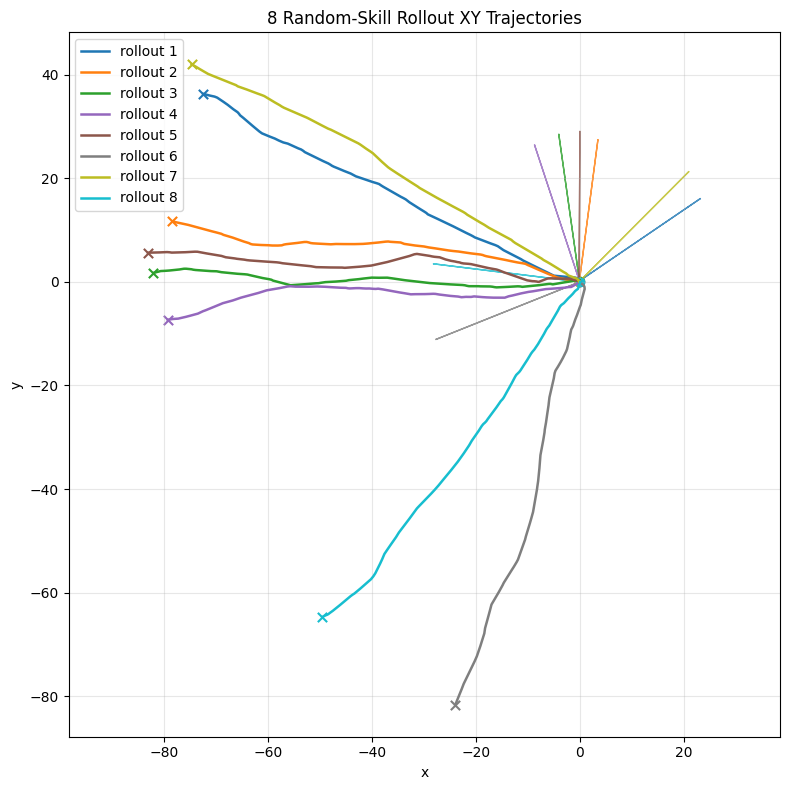

combined video: /home/helix/projects/METRA-Projects/FlashSAC/models/general/general_train/seed511527-0529-145128/eval_videos/rollout_grid.mp4
rollout 1: skill=[0.8257001 0.5641094], displacement=[-72.29582   36.148525]
  video: /home/helix/projects/METRA-Projects/FlashSAC/models/general/general_train/seed511527-0529-145128/eval_videos/rollout_01.mp4
rollout 2: skill=[0.12973243 0.9915491 ], displacement=[-78.2971    11.637164]
  video: /home/helix/projects/METRA-Projects/FlashSAC/models/general/general_train/seed511527-0529-145128/eval_videos/rollout_02.mp4
rollout 3: skill=[-0.13916652  0.990269  ], displacement=[-81.97617     1.5870887]
  video: /home/helix/projects/METRA-Projects/FlashSAC/models/general/general_train/seed511527-0529-145128/eval_videos/rollout_03.mp4
rollout 4: skill=[-0.3125364  0.9499059], displacement=[-79.25487    -7.3286853]
  video: /home/helix/projects/METRA-Projects/FlashSAC/models/general/general_train/seed511527-0529-145128/eval_videos/rollout_04.mp4
rollou

In [4]:
paths, combined_video_path = rollout_paths(
    agent.option_policy,
    env,
    sampler,
    num_paths=8,
    path_len=200,
    save_video=True,
    video_dir=video_dir,
    fps=20,
    save_combined_video=True,
)
plot_xy_rollouts(paths)
print(f"combined video: {combined_video_path}")

for idx, path in enumerate(paths, start=1):
    displacement = path["coords"][-1] - path["coords"][0]
    print(f"rollout {idx}: skill={path['skill']}, displacement={displacement}")
    print(f"  video: {path['video_path']}")